### Get basic info - shape, column names, datatypes, statistical summary

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
df = pd.read_csv('Iris.csv')
print ("First 5 rows:")
print(df.head())

First 5 rows:
   sepal.length  sepal.width  petal.length  petal.width variety
0           5.1          3.5           1.4          0.2  Setosa
1           4.9          3.0           1.4          0.2  Setosa
2           4.7          3.2           1.3          0.2  Setosa
3           4.6          3.1           1.5          0.2  Setosa
4           5.0          3.6           1.4          0.2  Setosa


In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns)
print("\nInfo:")
print(df.info())
print("\nStatistical summary:")
print(df.describe())

Shape: (150, 5)

Columns: Index(['sepal.length', 'sepal.width', 'petal.length', 'petal.width',
       'variety'],
      dtype='object')

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal.length  150 non-null    float64
 1   sepal.width   150 non-null    float64
 2   petal.length  150 non-null    float64
 3   petal.width   150 non-null    float64
 4   variety       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB
None

Statistical summary:
       sepal.length  sepal.width  petal.length  petal.width
count    150.000000   150.000000    150.000000   150.000000
mean       5.843333     3.057333      3.758000     1.199333
std        0.828066     0.435866      1.765298     0.762238
min        4.300000     2.000000      1.000000     0.100000
25%        5.100000     2.800000      1.600000     0.300000
50%        5.

### Check missing values, duplicates

In [4]:
print("Missing values:\n", df.isnull().sum())
print("\nDuplicates:", df.duplicated().sum())

Missing values:
 sepal.length    0
sepal.width     0
petal.length    0
petal.width     0
variety         0
dtype: int64

Duplicates: 1


### Check dataset balance

In [5]:
print(df['variety'].value_counts())

variety
Setosa        50
Versicolor    50
Virginica     50
Name: count, dtype: int64


### Histogram for features - univariate analysis

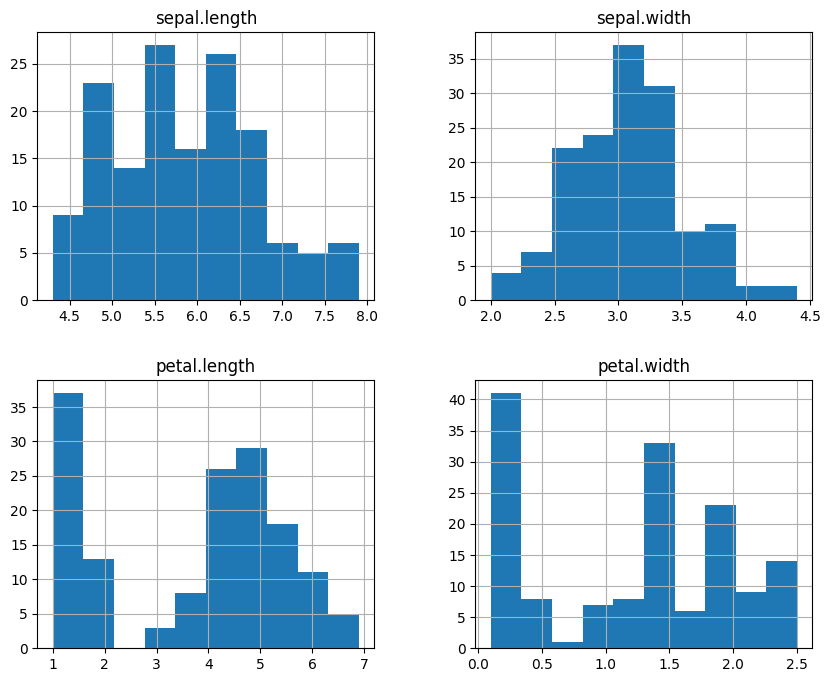

In [6]:
df.hist(figsize=(10,8))
plt.show()

###  Detect skewness

In [7]:
print(df.skew(numeric_only=True))

sepal.length    0.314911
sepal.width     0.318966
petal.length   -0.274884
petal.width    -0.102967
dtype: float64


### Boxplot - bivariate analysis

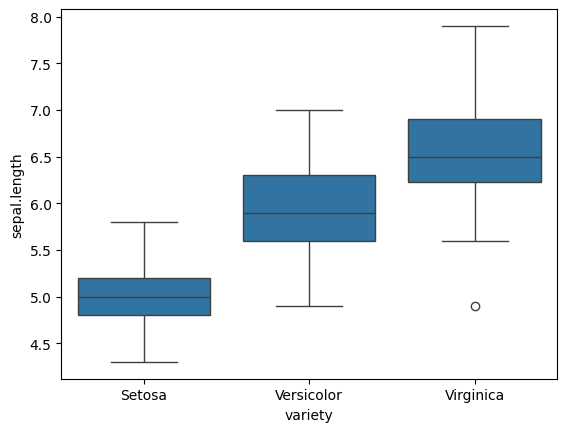

In [12]:
import seaborn as sns

sns.boxplot(x='variety', y='sepal.length', data=df)
plt.show()

### Scattered plot

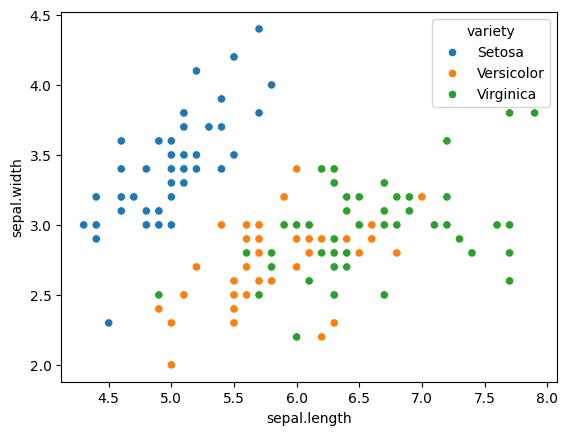

In [13]:
sns.scatterplot(x='sepal.length', y='sepal.width', hue='variety', data=df)
plt.show()

### Outlier detection

In [14]:
numeric_df = df.select_dtypes(include='number')

Q1 = numeric_df.quantile(0.25)
Q3 = numeric_df.quantile(0.75)
IQR = Q3 - Q1

outliers = numeric_df[((numeric_df < (Q1 - 1.5 * IQR)) | (numeric_df > (Q3 + 1.5 * IQR))).any(axis=1)]
print(outliers)

    sepal.length  sepal.width  petal.length  petal.width
15           5.7          4.4           1.5          0.4
32           5.2          4.1           1.5          0.1
33           5.5          4.2           1.4          0.2
60           5.0          2.0           3.5          1.0


### Correlation matrix and heatmap

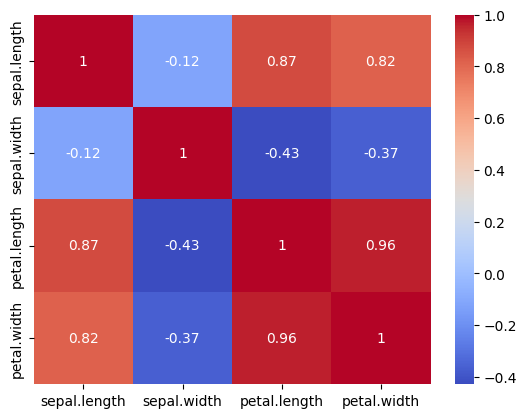

In [15]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.show()

In [19]:
# ===== ENCODING =====
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['variety'] = le.fit_transform(df['variety'])

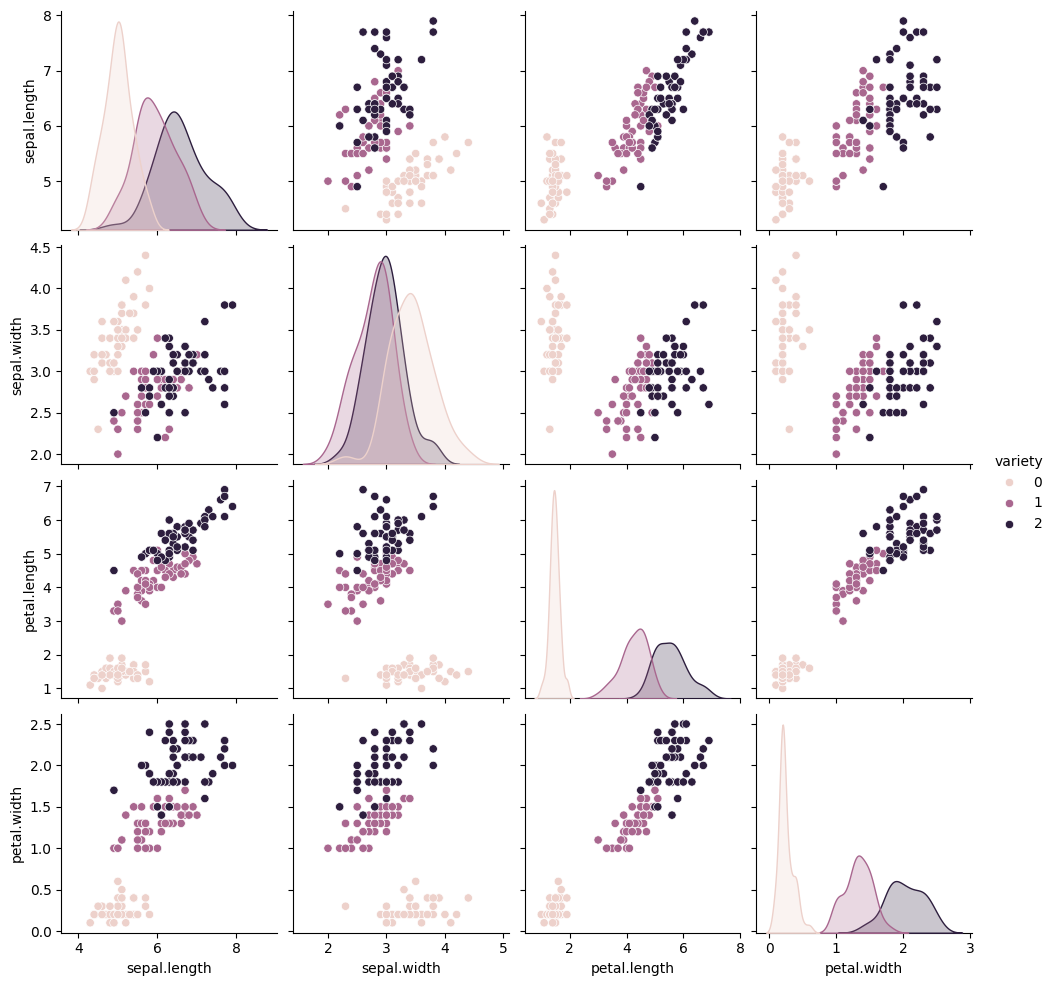

In [20]:
sns.pairplot(df, hue='variety')
plt.show()